In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt

In [ ]:
merged_df = pd.read_csv('merged_df.csv')
merged_df.head()

,value,savings,description_doge,total_obligation,award_amount,link,fain_key,date,agency,funding_opportunity_goals,...,recipient_name,recipient_parent_name,primary_place_of_performance_scope,primary_place_of_performance_country_code,primary_place_of_performance_country_name,primary_place_of_performance_state_name,cfda_title,business_types_description,action_type_description,sector
0,34998729.0,12993908.0,USAID¿S RESEARCH FOR SCALABLE SOLUTIONS (R4S) ...,22004821.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA1...,7200AA19CA00041,3/1/2025,USAID,NaN,...,FAMILY HEALTH INTERNATIONAL,NaN,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development
1,34998729.0,12993908.0,USAID¿S RESEARCH FOR SCALABLE SOLUTIONS (R4S) ...,22004821.0,50000.0,https://usaspending.gov/award/ASST_NON_7200AA1...,7200AA19CA00041,3/1/2025,USAID,NaN,...,FAMILY HEALTH INTERNATIONAL,NaN,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,CONTINUATION,International Development
2,34722274.0,9273274.0,TO PROVIDE SUPPORT FOR “FAMILY PLANNING AND RE...,25449000.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA2...,7200AA20CA00016,3/1/2025,USAID,ORACLE.SQL.CLOB@736008DE,...,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development
3,34722274.0,9273274.0,TO PROVIDE SUPPORT FOR “FAMILY PLANNING AND RE...,25449000.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA2...,7200AA20CA00016,3/1/2025,USAID,ORACLE.SQL.CLOB@736008DE,...,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development
4,140000000.0,73943882.0,THE MICROBICIDE 2021 INTRODUCTION AND ACCESS P...,66056118.0,0.0,https://usaspending.gov/award/ASST_NON_7200AA2...,7200AA21CA00011,3/1/2025,USAID,NOT APPLICABLE,...,FAMILY HEALTH INTERNATIONAL,FAMILY HEALTH INTERNATIONAL,SINGLE ZIP CODE,USA,UNITED STATES,NORTH CAROLINA,USAID FOREIGN ASSISTANCE FOR PROGRAMS OVERSEAS,NONPROFIT WITH 501C3 IRS STATUS (OTHER THAN AN...,REVISION,International Development


In [ ]:
# model 1: Linear regression (find correlation and build off of that)
rs = np.random.RandomState(0)
corr = merged_df.select_dtypes(include=[np.number]).corr()
corr[['savings']].style.background_gradient(cmap='coolwarm')

,savings
value,0.966671
savings,1.000000
total_obligation,0.890805
award_amount,-0.089046
total_obligated_amount,0.890828
federal_action_obligation,-0.086431
non_federal_funding_amount,-0.036686
action_date_fiscal_year,0.113063


Response (Y): savings
Predictive (X): sector, value, total_obligated_amount

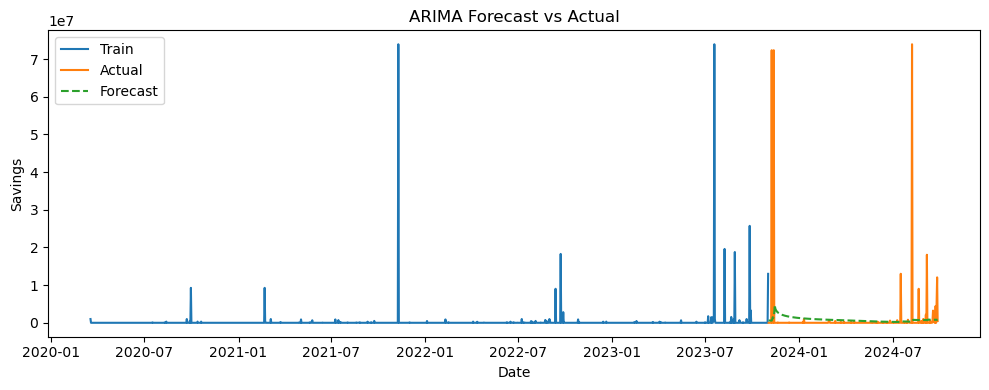

,Linear Regression,Decision Tree Regressor,Random Forest,Time Series (ARIMA)
OSR2,0.886,0.749,0.951,0.664
Out-of-sample MSE,20.6401,45.5618,8.8202,7.9661
Out-of-sample MAE,1.132,1.542,0.860,1.332


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

merged_df = pd.read_csv("merged_df.csv")

# make sure all columns that are numeric are actually numeric
numeric_cols = ['savings', 'value', 'total_obligation', 'award_amount']
for col in numeric_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

for col in numeric_cols:
    merged_df[col] = merged_df[col] / 1000000 #makes interpreting the comparison table a bit easier


#drop rows with missing target (reponse)
merged_df = merged_df.dropna(subset=['savings'])

#select features (predictor)
features = ['value', 'total_obligation', 'award_amount']  # numeric predictors

model_df = merged_df[['savings', 'sector'] + features].copy()
model_df = pd.get_dummies(model_df, columns=['sector'], drop_first=True) #makes dummy vars for sector

X = model_df.drop(columns=['savings'])
y = model_df['savings']

#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

def OSR2(model, X_test, y_test, y_train):
    y_pred = model.predict(X_test)
    sse = ((y_test - y_pred) ** 2).sum()
    sst = ((y_test - y_train.mean()) ** 2).sum()
    return 1 - sse / sst

#make models

# linear model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

#decision tree (hereby referred to as dt) model
dt_model = DecisionTreeRegressor(min_samples_leaf=5, ccp_alpha=0.001, random_state=0)
dt_model.fit(X_train, y_train)

#random forest (hereby referred to as rf) model
rf_model = RandomForestRegressor(n_estimators=500, random_state=0)
rf_model.fit(X_train, y_train)

# time series (hereby referred to as ts) model
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("merged_df.csv")

#use action_date because 'date' column only ranges 2/2025-5/2025
df['action_date'] = pd.to_datetime(df['action_date'], errors='coerce')
df = df.dropna(subset=['action_date'])
df = df.set_index('action_date')
df = df.sort_index()

df['savings'] = pd.to_numeric(df['savings'], errors='coerce')

#make daily aggregation
ts = df['savings'].resample('D').sum()

#split into train/test
h = max(1, int(len(ts) * 0.2))   # last 20% as test
train = ts.iloc[:-h]
test  = ts.iloc[-h:]

# fit an arima (autoregressive integrated moving average) model, commonly used when making a time series model for single variable (savings)
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# build forecast
pred = []
history = train.copy()

for t in range(len(test)):
    m = ARIMA(history, order=(1,1,1)).fit()
    f = m.forecast()[0]
    pred.append(f)

    # updates history with the actual observed test value (helps for plotting)
    new_point = pd.Series(test.iloc[t], index=[test.index[t]])
    history = pd.concat([history, new_point])

forecast_series = pd.Series(pred, index=test.index)

# osr2
sse_ts = np.sum((test - forecast_series)**2)
sst_ts = np.sum((test - train.mean())**2)
osr2_ts = 1 - sse/sst

# plot showing the predicted forecast against the actual data
plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(forecast_series.index, forecast_series, linestyle='--', label='Forecast')
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Savings")
plt.legend()
plt.tight_layout()
plt.show()



# comparison table
comparison_data = {
    'Linear Regression': [
        '{:.3f}'.format(OSR2(lin_model, X_test, y_test, y_train)),
        '{:.4f}'.format(mean_squared_error(y_test, lin_model.predict(X_test))),
        '{:.3f}'.format(mean_absolute_error(y_test, lin_model.predict(X_test)))
    ],
    'Decision Tree Regressor': [
        '{:.3f}'.format(OSR2(dt_model, X_test, y_test, y_train)),
        '{:.4f}'.format(mean_squared_error(y_test, dt_model.predict(X_test))),
        '{:.3f}'.format(mean_absolute_error(y_test, dt_model.predict(X_test)))
    ],
    'Random Forest': [
        '{:.3f}'.format(OSR2(rf_model, X_test, y_test, y_train)),
        '{:.4f}'.format(mean_squared_error(y_test, rf_model.predict(X_test))),
        '{:.3f}'.format(mean_absolute_error(y_test, rf_model.predict(X_test)))
    ],
    'Time Series (ARIMA)': [
    '{:.3f}'.format(osr2_ts),
    '{:.4f}'.format(mse_ts),
    '{:.3f}'.format(mae_ts)
]

}

comparison_table = pd.DataFrame(
    data=comparison_data,
    index=['OSR2', 'Out-of-sample MSE', 'Out-of-sample MAE']
)

# Style table
comparison_table.style.set_properties(**{'font-size': '12pt'}).set_table_styles(
    [{'selector': 'th', 'props': [('font-size', '10pt')]}]
)
